In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# unzip into the Colab session's local storage (faster than reading directly off Drive)
!unzip "/content/drive/MyDrive/Vehicles.yolov8.zip" -d "/content/dataset"

Mounted at /content/drive
Archive:  /content/drive/MyDrive/Vehicles.yolov8.zip
 extracting: /content/dataset/train/images/-B1ED27E9-03FD-44D8-970B-7B2700586B59-png_jpg.rf.GcS7rXthwoYdfu19gndK.jpg  
 extracting: /content/dataset/train/images/202104131309361_jpg.rf.HIhChGtLswYUIVDT9mrr.jpg  
 extracting: /content/dataset/train/images/140_jpg.rf.GSVf4ORBvR2m5cXsrQ21.jpg  
 extracting: /content/dataset/train/images/Image_013404_jpg.rf.H9m7kBKr9D6BpQ7Kt7EH.jpg  
 extracting: /content/dataset/train/images/ad4766d5f3124bc8_jpg.rf.GkVst1EQbmuQc5s637BV.jpg  
 extracting: /content/dataset/train/images/b883a730af5f9db4_jpg.rf.GbbQnPtGwNTuIkUN9kPc.jpg  
 extracting: /content/dataset/valid/images/-DA14FED7-2A8C-4E17-90A0-84E38A8D7FE8-png_jpg.rf.5kdkEZyjVql3i5jVYSde.jpg  
 extracting: /content/dataset/train/images/555_jpg.rf.Hfe9VurdqINQx2rbUUD1.jpg  
 extracting: /content/dataset/train/images/1c765efebc41876c_jpg.rf.HX20HojnyuCKMActGJ34.jpg  
 extracting: /content/dataset/train/images/5f630068e794c

In [ ]:
!ls /content/dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="traffic_custom"
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_custom, nbs=64, nms=False, 

RuntimeError: Dataset '/content/dataset/data.yaml' error ❌ '/content/dataset/data.yaml' does not exist


image 1/153 /content/dataset/test/images/-040585B0-923B-49A3-B6F7-D149A58534ED-png_jpg.rf.vfjZ60y5ZZdDIFc7VVf2.jpg: 640x640 1 car, 7.2ms
image 2/153 /content/dataset/test/images/-0585CFA0-7CD6-45D3-B7EB-1A109425F90D-png_jpg.rf.G1UqqZrJ8l11mUcdL4c0.jpg: 640x640 (no detections), 7.2ms
image 3/153 /content/dataset/test/images/-0945FFF1-B95A-49D9-AF38-521144CBA0A7-png_jpg.rf.fsMIWJVjSXnOpnzCUSXR.jpg: 640x640 2 cars, 7.5ms
image 4/153 /content/dataset/test/images/-0EA5B2D5-C63C-45B2-9048-072293BBA378-png_jpg.rf.oJDjKtNvVzpCPhFMZJl5.jpg: 640x640 1 car, 7.2ms
image 5/153 /content/dataset/test/images/-19FD5421-B6A2-4865-807F-65DEBDA59E17-png_jpg.rf.bWvP4WCm5nOp22SZe6OK.jpg: 640x640 1 car, 7.2ms
image 6/153 /content/dataset/test/images/-20370F09-C43F-47FF-AEDD-1508B10C5D42-png_jpg.rf.nhxeoDuxmpdnchIBTDDE.jpg: 640x640 (no detections), 7.2ms
image 7/153 /content/dataset/test/images/-251A7DC4-47FA-45BF-8F18-8C933578D147-png_jpg.rf.LWCzuA26fm2qRiAzoiNW.jpg: 640x640 1 car, 9.9ms
image 8/153 /conten

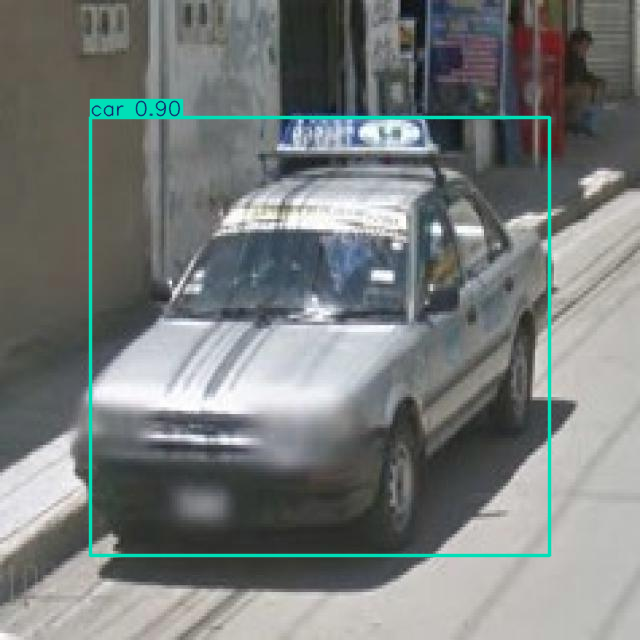

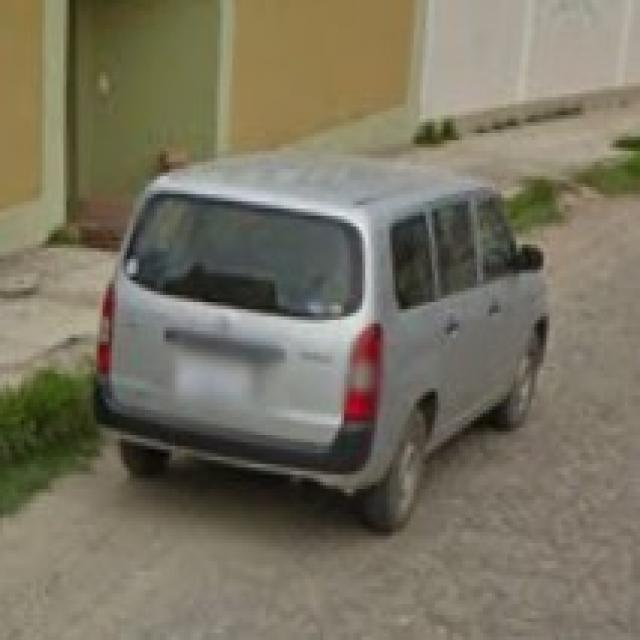

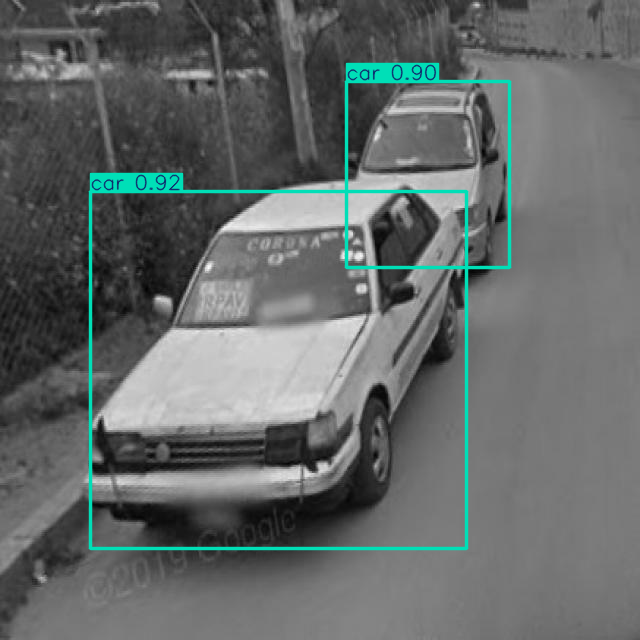


Finished processing all images!
Check the file browser on the left under 'runs/detect/predict' to see all your saved images.


In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow # Specific to Colab for showing images

# 1. Load your custom trained model
# Make sure the path matches what was printed at the end of your training
model_path = '/content/runs/detect/traffic_custom/weights/best.pt'
model = YOLO(model_path)

# 2. Define the path to your test folder in Google Drive
# Make sure your Drive is mounted!
# REPLACE this path with the actual path to your test folder in Drive
test_folder = '/content/dataset/test/images'

# 3. Run inference on the entire folder
# save=True tells YOLO to save copies of all images with the bounding boxes drawn
results = model.predict(source=test_folder, conf=0.25, save=True)

# 4. Display just the first 3 results to check them quickly
print("\nShowing the first 3 images...")
for i, r in enumerate(results):
    if i < 3: # Limit to 3 so your browser doesn't crash
        im_array = r.plot()
        cv2_imshow(im_array)

print("\nFinished processing all images!")
print("Check the file browser on the left under 'runs/detect/predict' to see all your saved images.")

In [ ]:
from ultralytics import YOLO

# 1. Load your best trained model
model_path = '/content/runs/detect/traffic_custom/weights/best.pt'
model = YOLO(model_path)

# 2. Define the path to your data.yaml file
# This is the file that tells YOLO where your train, val, and test folders are
data_yaml_path = '/content/dataset/data.yaml' # Updated to match the folder structure in the screenshot

# 3. Run evaluation (validation) specifically on the test set
# split="test" forces YOLO to use the test dataset instead of the validation dataset
print("Evaluating model on the Test set...")
metrics = model.val(data=data_yaml_path, split="test")

# 4. Print the key metrics
print("\n--- Test Set Results ---")
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.4f}")
print(f"Mean Average Precision (mAP50-95): {metrics.box.map:.4f}")

Evaluating model on the Test set...
Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1766.5±764.3 MB/s, size: 40.5 KB)
val: Scanning /content/dataset/test/labels... 153 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 153/153 2.3Kit/s 0.1s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.4it/s 2.9s
                   all        153        215      0.945      0.821      0.911      0.662
                   Bus         17         26      0.904      0.731      0.889      0.707
            Motorcycle         46         66      0.967       0.97      0.969      0.546
                   car         84        104      0.979      0.846       0.92      0.722
                 truck         15         19      

In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO("/content/runs/detect/traffic_custom/weights/best.pt")

VEHICLE_CLASSES = set(model.names.values())  # or restrict to specific ones you trained
LINE_Y = 300  # tune this after watching your test video once

def process_video(video_path, output_path="output.mp4"):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w, h = int(cap.get(3)), int(cap.get(4))
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    counts = {cls: 0 for cls in VEHICLE_CLASSES}
    counted_ids = set()

    results = model.track(source=video_path, persist=True, stream=True, verbose=False)

    for r in results:
        frame = r.orig_img.copy()
        cv2.line(frame, (0, LINE_Y), (w, LINE_Y), (0, 255, 255), 2)

        if r.boxes.id is not None:
            for box, track_id, cls_id, conf in zip(r.boxes.xyxy, r.boxes.id, r.boxes.cls, r.boxes.conf):
                x1, y1, x2, y2 = map(int, box)
                cls_name = model.names[int(cls_id)]
                uid = int(track_id)
                cy = (y1 + y2) // 2

                if uid not in counted_ids and cy > LINE_Y:
                    counted_ids.add(uid)
                    counts[cls_name] += 1

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 200, 0), 2)
                cv2.putText(frame, f"{cls_name} {uid}", (x1, y1 - 8),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 2)

        y_offset = 30
        for cls, n in counts.items():
            cv2.putText(frame, f"{cls}: {n}", (10, y_offset),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            y_offset += 25

        out.write(frame)

    cap.release()
    out.release()
    return output_path, counts

output_path, final_counts = process_video("/content/your_test_video.mp4")
print(final_counts)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/traffic_custom/weights/best.pt'

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.5 MB/s eta 0:00:00
